In [101]:
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import TitanicDataHelper
from utils.evaluation_utils import EvaluationHelper
import warnings
warnings.filterwarnings("ignore")

## Data Visualization

In [102]:
x_train, x_test, y_train, y_test = TitanicDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 10), (179, 10), (712,), (179,))

In [103]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,UncommonTitle,YoungTitle,Sex_male,Embarked_Q,Embarked_S
709,0.824654,-0.091831,0.445182,0.705697,-0.339157,-0.174207,1.737341,0.741906,-0.308627,-1.593335
439,-0.376069,0.132682,-0.481630,-0.493483,-0.429806,-0.174207,-0.574784,0.741906,-0.308627,0.626733
840,0.824654,-0.690532,-0.481630,-0.493483,-0.478991,-0.174207,-0.574784,0.741906,-0.308627,0.626733
720,-0.376069,-1.738261,-0.481630,0.705697,-0.000034,-0.174207,1.737341,-1.345987,-0.308627,0.626733
39,0.824654,-1.139559,0.445182,-0.493483,-0.415639,-0.174207,1.737341,-1.345987,-0.308627,-1.593335


In [104]:
y_train.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

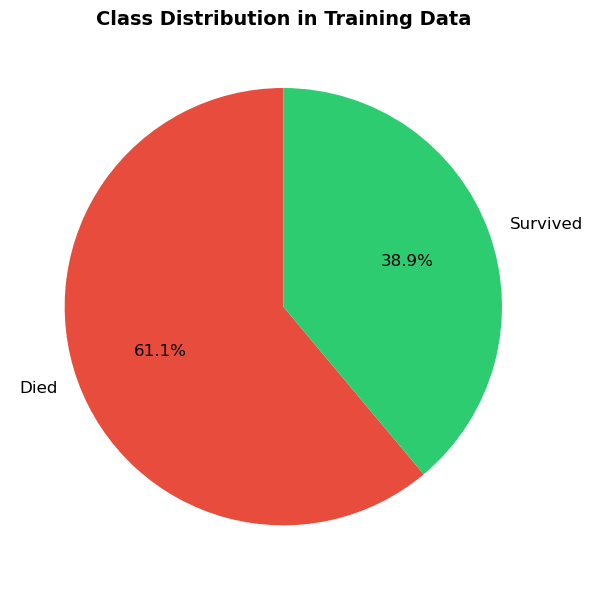

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [105]:
TitanicDataHelper.plot_outcome_distribution(x_train, y_train)

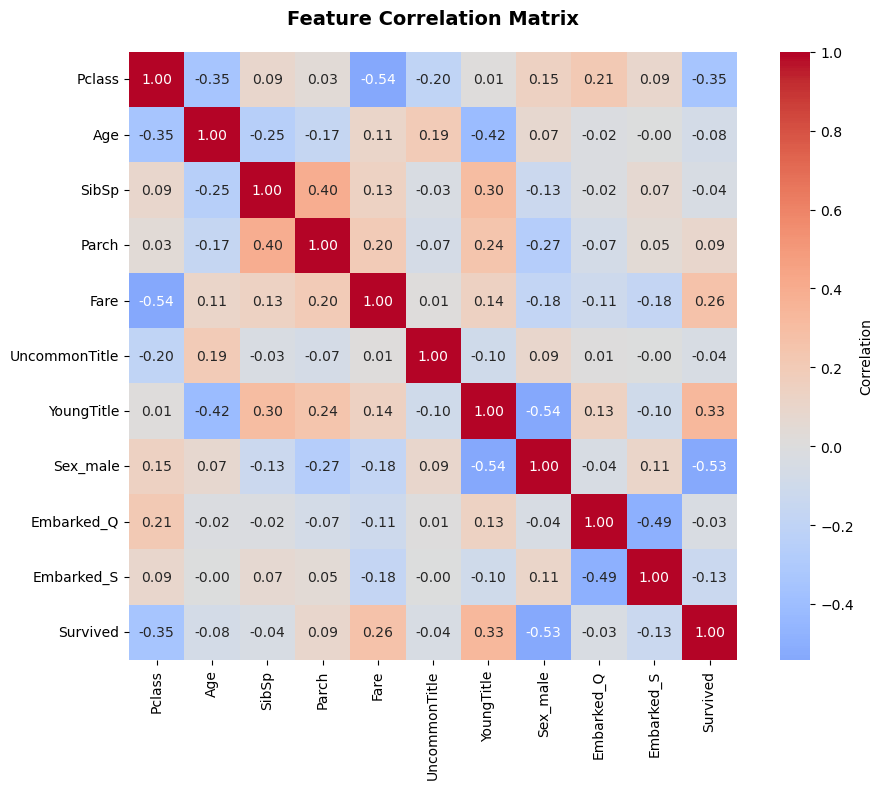

In [106]:
TitanicDataHelper.plot_correlation(x_train, y_train)

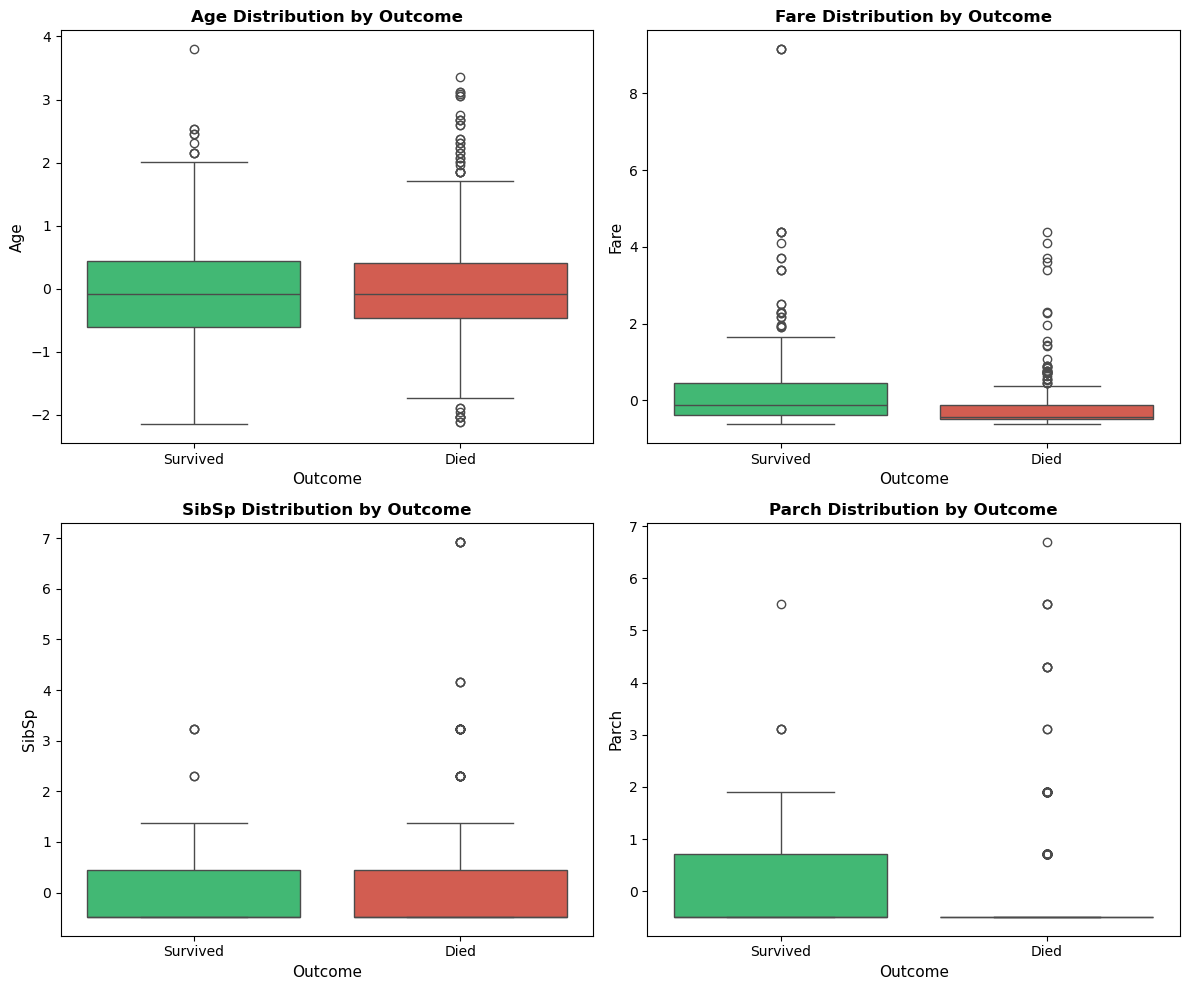

In [107]:
TitanicDataHelper.plot_boxplots(x_train, y_train)

## Model Training

In [108]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [109]:
def relu(input):
    return np.maximum(0, input)

def sigmoid(input):
    return 1 / (1 + np.exp(-input))

class Layer:
    def __init__(self, weights, biases):
        self.weights = weights
        self.biases = biases
    
    def forward(self, input):
        dot_product = np.dot(input, self.weights)
        return dot_product + self.biases

class ReluLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return relu(result)

class SigmoidLayer(Layer):
    def __init__(self, weights, biases):
        super().__init__(weights, biases)
    
    def forward(self, input):
        result = super().forward(input)
        return sigmoid(result)

In [110]:
def initialize_layers(input_size, hidden1_size, hidden2_size, output_size):
    hidden1_weights = np.random.normal(0, np.sqrt(2.0 / input_size), size=(input_size, hidden1_size))
    hidden1_biases = np.zeros(shape=(hidden1_size,))
    hidden1_layer = ReluLayer(hidden1_weights, hidden1_biases)

    hidden2_weights = np.random.normal(0, np.sqrt(2.0 / hidden1_size), size=(hidden1_size, hidden2_size))
    hidden2_biases = np.zeros(shape=(hidden2_size,))
    hidden2_layer = ReluLayer(hidden2_weights, hidden2_biases)

    output_weights = np.random.normal(0, np.sqrt(2.0 / hidden2_size), size=(hidden2_size, output_size))
    output_biases = np.zeros(shape=(output_size,))
    output_layer = SigmoidLayer(output_weights, output_biases)
    
    return hidden1_layer, hidden2_layer, output_layer

In [111]:
hidden1_layer, hidden2_layer, output_layer = initialize_layers(input_size=10, hidden1_size=20, hidden2_size=10, output_size=1)

In [112]:
def forward(x):
    hidden1_output = hidden1_layer.forward(x)
    hidden2_output = hidden2_layer.forward(hidden1_output)
    output = output_layer.forward(hidden2_output)
    return hidden1_output, hidden2_output, output

In [113]:
def compute_loss(y_true, prob):
    epsilon = 1e-15
    prob = np.clip(prob, epsilon, 1 - epsilon)
    loss = -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))
    return loss

In [114]:
def clip_grad(grad, clip_value=5.0):
    norm = np.linalg.norm(grad)
    if norm > clip_value:
        grad = grad * (clip_value / norm)
    return grad

def backward(x, hidden1_output, hidden2_output, y_pred, y_true, learning_rate=0.01):
    output_error = y_pred - y_true
    output_weight_grad = np.outer(hidden2_output, output_error)
    output_bias_grad = output_error
    
    hidden2_error = np.dot(output_layer.weights, output_error) * (hidden2_output > 0)
    hidden2_weight_grad = np.outer(hidden1_output, hidden2_error)
    hidden2_bias_grad = hidden2_error
    
    hidden1_error = np.dot(hidden2_layer.weights, hidden2_error) * (hidden1_output > 0)
    hidden1_weight_grad = np.outer(x, hidden1_error)
    hidden1_bias_grad = hidden1_error
    
    output_weight_grad = clip_grad(output_weight_grad)
    output_bias_grad = clip_grad(output_bias_grad)
    hidden2_weight_grad = clip_grad(hidden2_weight_grad)
    hidden2_bias_grad = clip_grad(hidden2_bias_grad)
    hidden1_weight_grad = clip_grad(hidden1_weight_grad)
    hidden1_bias_grad = clip_grad(hidden1_bias_grad)
    
    output_layer.weights -= learning_rate * output_weight_grad
    output_layer.biases -= learning_rate * output_bias_grad
    hidden2_layer.weights -= learning_rate * hidden2_weight_grad
    hidden2_layer.biases -= learning_rate * hidden2_bias_grad
    hidden1_layer.weights -= learning_rate * hidden1_weight_grad
    hidden1_layer.biases -= learning_rate * hidden1_bias_grad    

In [115]:
epochs = 100
epoch_losses = []

learning_rate = 0.001

for epoch in range(epochs):
    total_loss = 0
    
    for i in range(len(x_train)):
        x = x_train[i]
        y_true = y_train[i]

        hidden1_output, hidden2_output, y_pred = forward(x)

        loss = compute_loss(y_true, y_pred[0])
    
        total_loss += loss

        backward(x, hidden1_output, hidden2_output, y_pred, y_true, learning_rate)

    avg_loss = total_loss / len(x_train)
        
    epoch_losses.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch: {epoch + 1}/{epochs} | Avg. Loss: {avg_loss:.6f}")

Epoch: 50/100 | Avg. Loss: 0.386496
Epoch: 100/100 | Avg. Loss: 0.365465


In [116]:
def predict(x):
    _, _, y_pred = forward(x)
    return (y_pred[0] > 0.5).astype(int), y_pred[0]

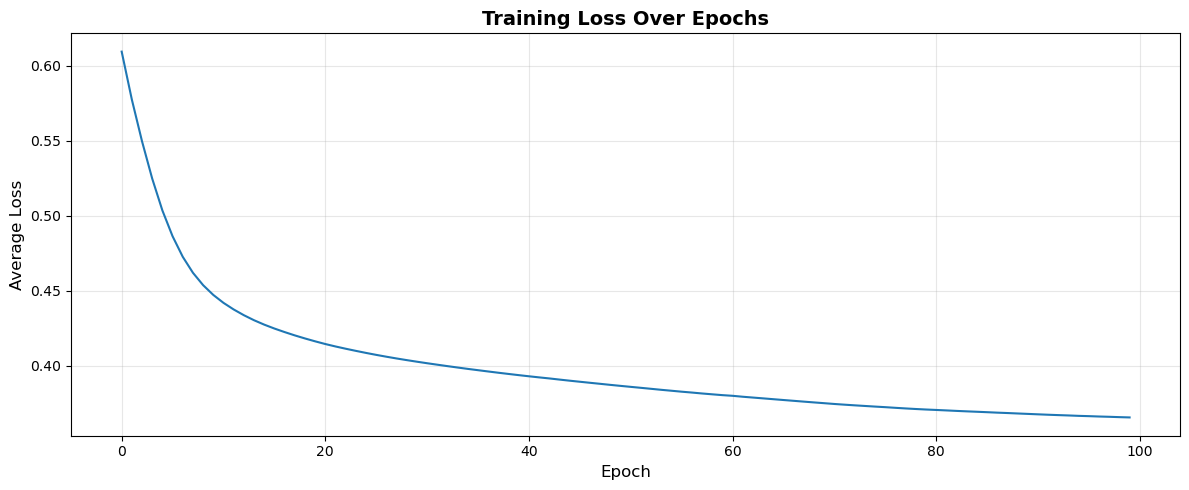

Initial loss: 0.609270
Final loss: 0.365465
Loss reduction: 40.02%


In [117]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(epoch_losses, linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Training Loss Over Epochs", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {epoch_losses[0]:.6f}")
print(f"Final loss: {epoch_losses[-1]:.6f}")
print(f"Loss reduction: {(epoch_losses[0] - epoch_losses[-1])/epoch_losses[0]*100:.2f}%")

## Model Evaluation

In [118]:
predictions = []
probabilities = []

for x in x_test:
    prediction, prob = predict(x)
    predictions.append(prediction)
    probabilities.append(prob)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

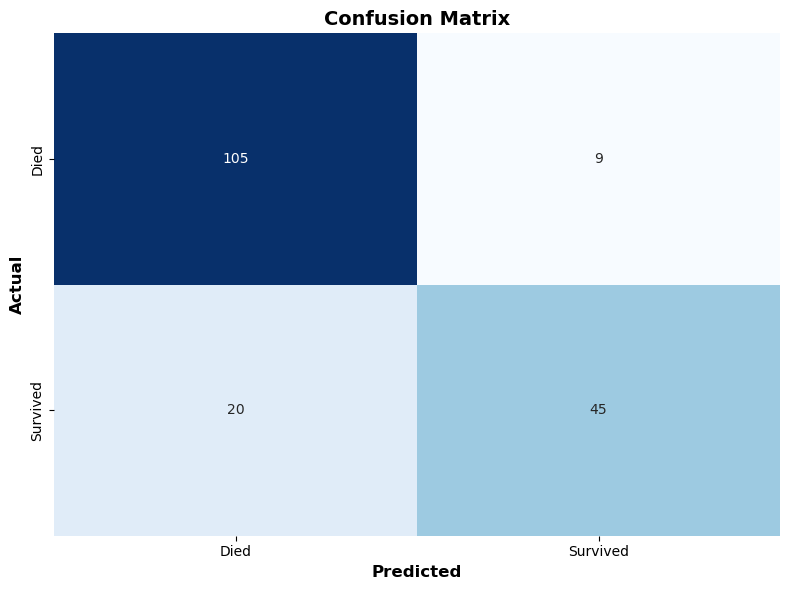

True Negatives: 105
False Positives: 9
False Negatives: 20
True Positives: 45

Sensitivity (Recall): 0.6923
Specificity: 0.9211
Precision: 0.8333
Accuracy: 0.8380
F1 Score: 0.7563


In [119]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Died", "Survived"])

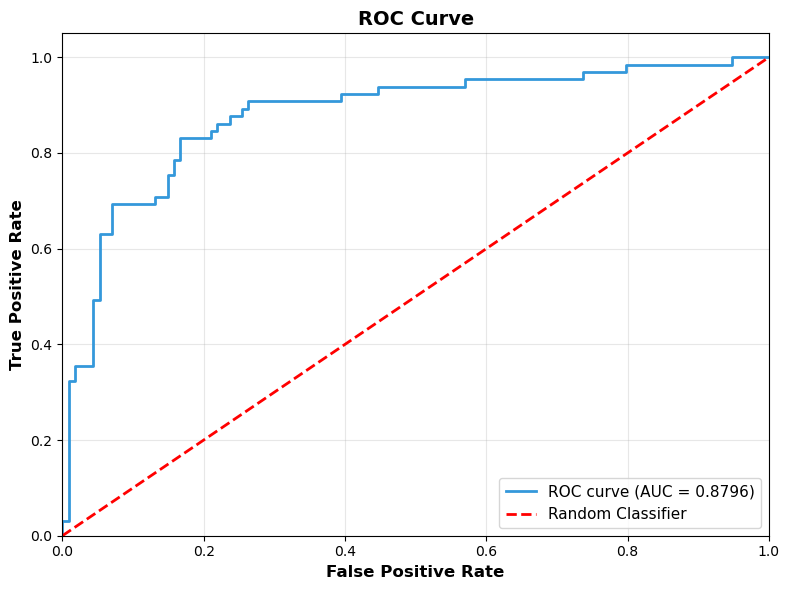

Area Under the Curve (AUC): 0.8796


In [120]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)